In [100]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
#from jaxstar.mistfit import *

In [101]:
from jax.config import config
config.update('jax_enable_x64', True)

In [102]:
from jax import vmap

In [103]:
smp_label = 1
smp_num = 300

In [104]:
d = pd.read_csv("../acheron/tests_simulation/hierarchical_recovery/gpgyro_func%d_s%d.csv"%(smp_label,smp_num))
dsmp = np.load("../acheron/tests_simulation/hierarchical_recovery/gpgyro_func%d_s%d.npz"%(smp_label,smp_num))
idx = (d.teff_true > 5500)
d = d[idx].reset_index(drop=True)
isosamples = dsmp['samples'][idx]

In [105]:
d.keys()

Index(['kepid', 'iso_age', 'iso_age_upp', 'iso_age_low', 'iso_mass',
       'iso_mass_upp', 'iso_mass_low', 'iso_radius', 'iso_radius_upp',
       'iso_radius_low', 'iso_teff', 'iso_teff_upp', 'iso_teff_low', 'iso_feh',
       'iso_feh_upp', 'iso_feh_low', 'iso_kmag', 'iso_kmag_upp',
       'iso_kmag_low', 'iso_parallax', 'iso_parallax_upp', 'iso_parallax_low',
       'eep_true', 'teff_obs', 'feh_obs', 'kmag_obs', 'parallax_obs',
       'teff_error', 'feh_error', 'kmag_error', 'parallax_error', 'age_true',
       'mass_true', 'radius_true', 'teff_true', 'feh_true', 'kmag_true',
       'parallax_true', 'dteff', 'dsigmateff', 'dfeh', 'dsigmafeh', 'dkmag',
       'dsigmakmag', 'dparallax', 'dsigmaparallax', 'dsigmaobs', 'idx'],
      dtype='object')

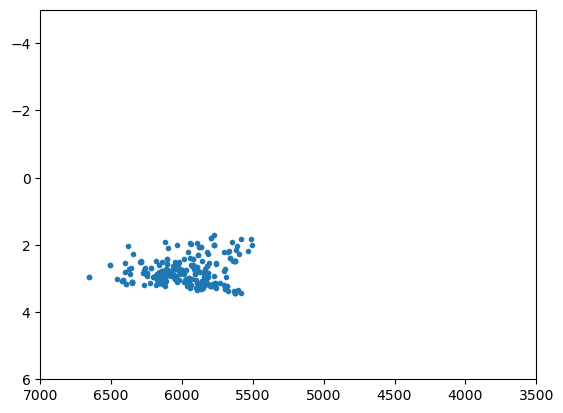

In [106]:
plt.xlim(7000, 3500)
plt.ylim(6, 0-5)
plt.plot(np.array(d.teff_true), np.array(d.kmag_true)-10+5*np.log10(d.parallax_true), '.')

In [107]:
len(d), len(isosamples)

(257, 257)

In [108]:
def prot_given_stellar_params(p):
    mass, age = p
    return mass**(-3.) * (age / 4.6)**0.5 * 25.

def prot_power(age, beta, gamma):
    return gamma * (age / 4.6)**beta

def prot_wmb(age, beta, gamma, age_crit=3., beta2=0.1):
    return jnp.where(age < age_crit, prot_power(age, beta, gamma), 
                     (age_crit/4.6)**(beta-beta2) * prot_power(age, beta2, gamma))

In [109]:
x = np.linspace(0, 8, 1000)

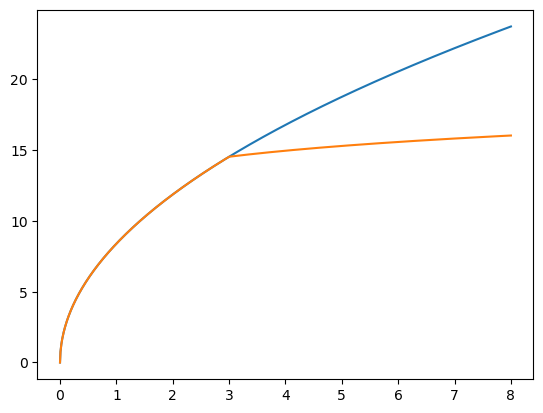

In [110]:
plt.plot(x, prot_power(x, 0.5, 18.))
plt.plot(x, prot_wmb(x, 0.5, 18., 3., 0.1))

In [127]:
prot_func = prot_power
prot_func = prot_wmb

In [128]:
N = len(d)
np.random.seed(123)
#prot = np.array(prot_given_stellar_params([d.mass_true, d.age_true]))
prot = prot_func(np.array(d.age_true), 0.5, 18.)
cosi = np.random.rand(N)
vsini = 50.6 * d.radius_true / prot * np.sqrt(1.-cosi**2)
d['prot_true'] = prot
d['vsini_true'] = vsini
d['prot_obs'] = prot + 0.05 * np.random.randn(N) * prot
d['prot_sigma'] = 0.05 * prot
d['vsini_obs'] = np.abs(vsini + np.random.randn(N))
d['vsini_sigma'] = 1.
d['cosi_true'] = cosi

In [129]:
vsini_obs, vsini_err = jnp.array(d['vsini_obs']), jnp.array(d['vsini_sigma'])

In [130]:
np.mean(vsini_obs)

DeviceArray(4.27188747, dtype=float64)

In [131]:
3e5/65000

4.615384615384615

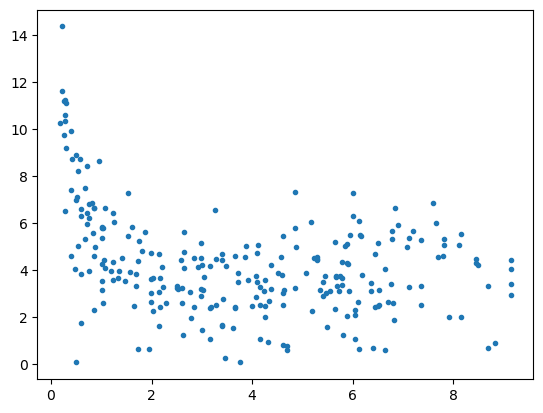

In [132]:
#plt.yscale("log")
plt.plot(d.age_true, vsini_obs, '.')

In [133]:
from jax import random
rng_key = random.PRNGKey(0)

In [134]:
from jax.scipy.special import logsumexp

def prot_model(mass, age, alpha, beta, gamma):
    return mass**(alpha) * (age / 4.6)**beta * gamma

Nxbin = 25
xbins = jnp.linspace(0, 14, Nxbin+1)
def prot_model_step(age, logprot):
    return 10**logprot[jnp.digitize(age, xbins)-1]

def loglike_vsini_single(vsini_obs, vsini_err, prot, rad, cosi):
    vsini_model = 50.6 * rad / prot * jnp.sqrt(1.-cosi[:,None]**2)
    return -0.5 * ((vsini_obs[:,None] - vsini_model)**2 / vsini_err[:,None]**2)

In [135]:
import numpyro
from numpyro.infer import NUTS, MCMC
import numpyro.distributions as dist

def model(vsini_obs, vsini_err, isosamples, Nsamples=10000):  
    N = len(vsini_obs)
    ones = jnp.ones(N)

    cosi = numpyro.sample("cosi", dist.Uniform(low=0*ones, high=1.*ones))
    beta = numpyro.sample("beta", dist.HalfNormal(3))
    gamma = numpyro.sample("gamma", dist.TruncatedNormal(25, 10, low=5.))
    prot_pred = prot_power(isosamples[:N,:Nsamples,1], beta, gamma)
    
    """
    logprot = numpyro.sample("logprot", dist.Normal(loc=jnp.ones(Nxbin), scale=jnp.ones(Nxbin)))
    prot_pred = prot_model_step(isosamples[:N,:Nsamples,1], logprot)
    """
    
    loglike = jnp.sum(logsumexp(loglike_vsini_single(vsini_obs, vsini_err, prot_pred, isosamples[:N,:Nsamples,2], cosi), axis=1))
    numpyro.factor("loglike", loglike)
    

def model(vsini_obs, vsini_err, isosamples, Nsamples=10000):  
    N = len(vsini_obs)
    ones = jnp.ones(N)

    cosi = numpyro.sample("cosi", dist.Uniform(low=0*ones, high=1.*ones))
    beta = numpyro.sample("beta", dist.HalfNormal(3))
    gamma = numpyro.sample("gamma", dist.TruncatedNormal(25, 10, low=5.))
    
    age_crit = numpyro.sample("age_crit", dist.Uniform(0, 10))
    
    prot_pred = prot_wmb(isosamples[:N,:Nsamples,1], beta, gamma, age_crit, beta2=0.1)

    loglike = jnp.sum(logsumexp(loglike_vsini_single(vsini_obs, vsini_err, prot_pred, isosamples[:N,:Nsamples,2], cosi), axis=1))
    numpyro.factor("loglike", loglike)

In [136]:
kernel = NUTS(model, target_accept_prob=0.95, max_tree_depth=10)

In [137]:
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=500)

In [138]:
mcmc.run(rng_key, vsini_obs, vsini_err, isosamples, Nsamples=1000)

sample: 100%|██████████████████████| 1000/1000 [05:51<00:00,  2.85it/s, 63 steps of size 6.88e-02. acc. prob=0.98]


In [141]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  age_crit      4.70      1.40      4.47      2.70      6.53    213.50      1.00
      beta      0.46      0.06      0.45      0.37      0.54    168.00      1.00
   cosi[0]      0.42      0.23      0.44      0.00      0.74    588.86      1.01
   cosi[1]      0.27      0.18      0.25      0.01      0.54    677.79      1.00
   cosi[2]      0.30      0.20      0.27      0.00      0.60    564.33      1.00
   cosi[3]      0.34      0.22      0.31      0.00      0.66    758.24      1.00
   cosi[4]      0.47      0.27      0.48      0.00      0.84   1282.39      1.00
   cosi[5]      0.41      0.23      0.41      0.05      0.76    812.57      1.00
   cosi[6]      0.89      0.12      0.93      0.74      1.00    539.59      1.00
   cosi[7]      0.86      0.15      0.90      0.67      1.00    590.53      1.00
   cosi[8]      0.62      0.25      0.68      0.21      0.99    756.23      1.00
   cosi[9]      0.40      0

In [125]:
samples_power = mcmc.get_samples()

In [142]:
samples = mcmc.get_samples()

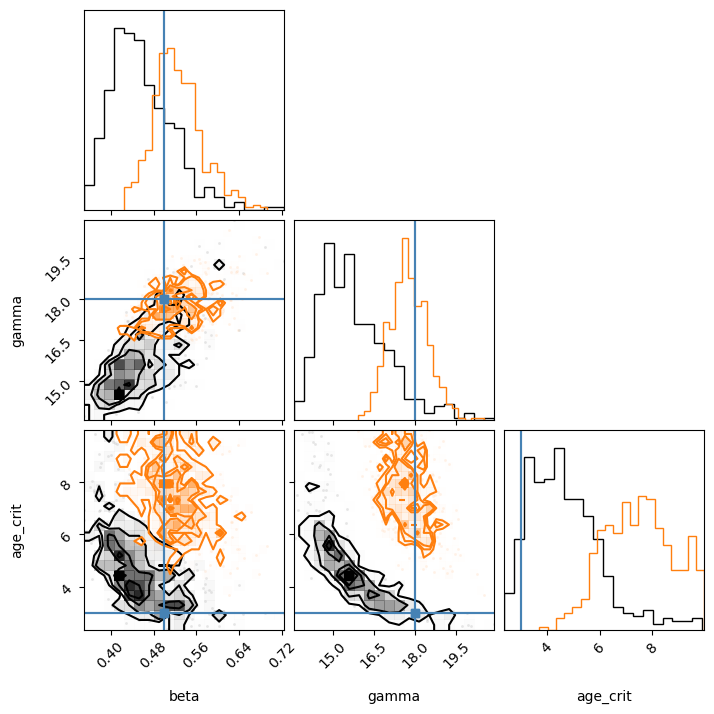

In [143]:
keys = ['beta', 'gamma', 'age_crit']
fig = corner.corner(np.array([samples[key] for key in keys]).T, labels=keys, 
                    truths=[0.5, 18, 3.])
fig = corner.corner(np.array([samples_power[key] for key in keys]).T, labels=keys, 
                    truths=[0.5, 18, 3.], fig=fig, color='C1')

In [144]:
prot_wmb_vmap = vmap(prot_wmb, (None,0,0,0), 0)
models = prot_wmb_vmap(x, samples['beta'], samples['gamma'], samples['age_crit'])
models_power = prot_wmb_vmap(x, samples_power['beta'], samples_power['gamma'], samples_power['age_crit'])

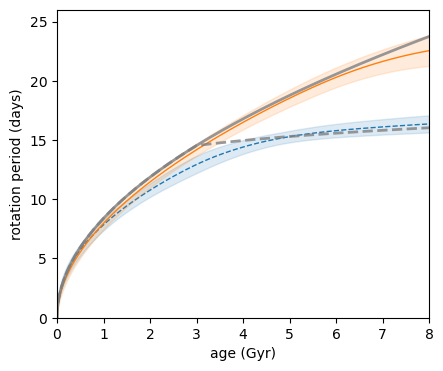

In [161]:
plt.figure(figsize=(6*0.8,5*0.8))
plt.ylim(0., 26)
plt.xlim(0.0, 8)
plt.xlabel("age (Gyr)")
plt.ylabel("rotation period (days)")
#plt.yscale("log")
plt.plot(x, prot_power(x, 0.5, 18.), color='gray', lw=2, alpha=0.8)
plt.plot(x, prot_wmb(x, 0.5, 18.), color='gray', ls='dashed', lw=2, alpha=0.8)
#plt.plot(d.age_true, d.prot_true, '.', color='C0', markersize=2)
mu, sigma = np.mean(models, axis=0), np.std(models, axis=0)
plt.plot(x, mu, color='C0', zorder=-1000, ls='dashed', lw=1)
plt.fill_between(x, mu-sigma, mu+sigma, alpha=0.15, color='C0', zorder=-1000)
mu, sigma = np.mean(models_power, axis=0), np.std(models_power, axis=0)
plt.plot(x, mu, color='C1', zorder=-1000, lw=1)
plt.fill_between(x, mu-sigma, mu+sigma, alpha=0.15, color='C1', zorder=-1000)
plt.savefig("simulation.png", dpi=200, bbox_inches="tight")

In [99]:
np.shape(samples['logprot'])
prot_model_step_vmap = vmap(prot_model_step, (None,0), 0)

In [100]:
x = np.linspace(0, 14, 1000)
models = prot_model_step_vmap(x, samples['logprot'])

In [101]:
np.shape(models)

(250, 1000)

In [ ]:
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.errorbar(d.cosi_true, np.median(samples['cosi'], axis=0), fmt='o', 
             yerr=np.std(samples['cosi'], axis=0),lw=1)

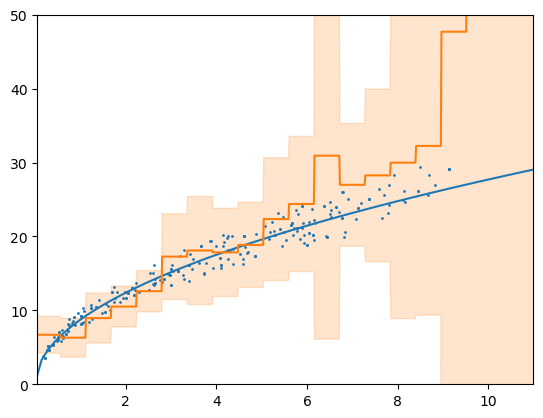

In [102]:
plt.ylim(0, 50)
plt.xlim(0.05, 11)
#plt.yscale("log")
plt.plot(a, prot_model(m, a, -3, 0.5, 25.), color='C0')
plt.plot(d.age_true, d.prot_true, '.', color='C0', markersize=2)
mu, sigma = np.mean(models, axis=0), np.std(models, axis=0)
plt.plot(x, mu, color='C1')
plt.fill_between(x, mu-sigma, mu+sigma, alpha=0.2, color='C1')

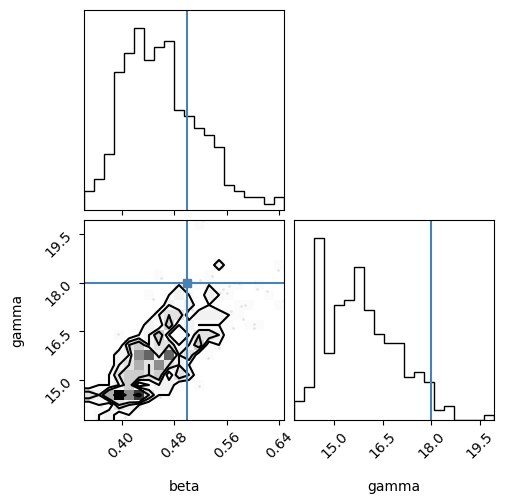

In [37]:
import corner
keys = ['alpha', 'beta', 'gamma'][1:]
fig = corner.corner(np.array([samples[key] for key in keys]).T, labels=keys, 
                    truths=[0.5, 18])

In [48]:
def prot_model_(mass, age, alpha, beta, gamma):
    return (mass*(age/age))**(alpha) * (age / 4.6)**beta * gamma

prot_model_vmap = vmap(prot_model_, (0, None, 0, 0, 0), 0)

In [49]:
a = np.linspace(1e-3, 14, 100)
m = 1.1 * a / a

In [50]:
models = prot_model_vmap(np.random.rand(len(samples['alpha']))*0.1+1.05, a, samples['alpha'], samples['beta'], samples['gamma'])

In [ ]:
#plt.ylim(0, 50)
plt.xlim(0.05, 11)
#plt.yscale("log")
plt.plot(a, prot_model(m, a, -3, 0.5, 25.), color='C0')
#plt.plot(a, prot_given_stellar_params([m,a]), color='C2')
plt.plot(d.age_true, d.prot_true, '.', color='C0', markersize=2)
mu, sigma = np.mean(models, axis=0), np.std(models, axis=0)
plt.plot(a, mu, color='C1')
plt.fill_between(a, mu-sigma, mu+sigma, alpha=0.2, color='C1')
"""
for i in range(50):
    al, be, ga = samples['alpha'][i], samples['beta'][i], samples['gamma'][i]
    #al, be, ga = -3, samples['beta'][i], samples['gamma'][i]
    #print (al, be, ga)
    plt.plot(a, prot_model(m, a, al, be, ga), alpha=0.1, color='C1')
"""

In [153]:
prot_model_vmap = vmap(prot_power, (None,0,0), 0)
models = prot_model_vmap(a, samples['beta'], samples['gamma'])

"\nfor i in range(50):\n    al, be, ga = samples['alpha'][i], samples['beta'][i], samples['gamma'][i]\n    #al, be, ga = -3, samples['beta'][i], samples['gamma'][i]\n    #print (al, be, ga)\n    plt.plot(a, prot_model(m, a, al, be, ga), alpha=0.1, color='C1')\n"

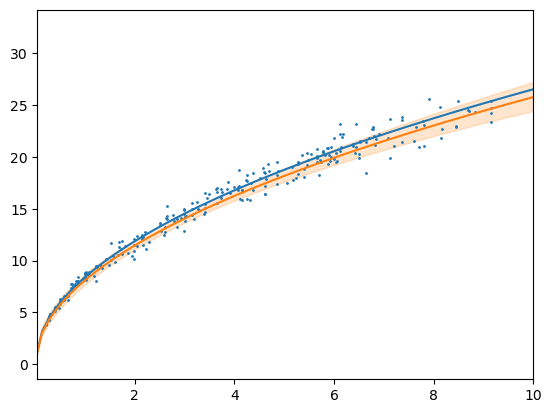

In [158]:
#plt.ylim(0, 50)
plt.xlim(0.05, 10)
#plt.yscale("log")
plt.plot(a, prot_power(a, 0.5, 18.), color='C0')
#plt.plot(a, prot_given_stellar_params([m,a]), color='C2')
plt.plot(d.age_true, d.prot_obs, '.', color='C0', markersize=2)
mu, sigma = np.mean(models, axis=0), np.std(models, axis=0)
plt.plot(a, mu, color='C1')
plt.fill_between(a, mu-sigma, mu+sigma, alpha=0.2, color='C1')
"""
for i in range(50):
    al, be, ga = samples['alpha'][i], samples['beta'][i], samples['gamma'][i]
    #al, be, ga = -3, samples['beta'][i], samples['gamma'][i]
    #print (al, be, ga)
    plt.plot(a, prot_model(m, a, al, be, ga), alpha=0.1, color='C1')
"""